# Asymmetry as non-recoverable noise increases

This notebook keeps the same Gaussian source and the same random target-only
direction at every point of the sweep. Only the amplitude of that independent
direction changes. Consequently, differences across the x-axis are caused by
noise scale rather than by new random draws.

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in [cwd, *cwd.parents] if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    project_config = yaml.safe_load(f)
paths = project_config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from II_analyses.asymmetry_pipeline import (
    generate_gaussian_with_orthogonal_noise,
    run_asymmetry_pipeline,
)

plt.rcParams.update(
    {"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False}
)

In [2]:
@dataclass
class Cfg:
    n_samples: int = 600
    noise_levels: tuple = (0.0, 0.05, 0.1, 0.2, 0.4, 0.7, 1.0, 1.5, 2.0)
    signal_scales: tuple = (2.0, 0.5)
    seed: int = 20260812
    source_RDM_metric: str = "euclidean"
    target_RDM_metric: str = "euclidean"
    k: int = 5
    singular_value_rtol: float | None = None
# EOC


cfg = Cfg()
cfg

Cfg(n_samples=600, noise_levels=(0.0, 0.05, 0.1, 0.2, 0.4, 0.7, 1.0, 1.5, 2.0), signal_scales=(2.0, 0.5), seed=20260812, source_RDM_metric='euclidean', target_RDM_metric='euclidean', k=5, singular_value_rtol=None)

## Geometry at three representative noise levels

The first two target coordinates are an invertible, anisotropically scaled copy
of `X`. The third coordinate is independent of `X`, so no source-to-target
mapping can recover it.

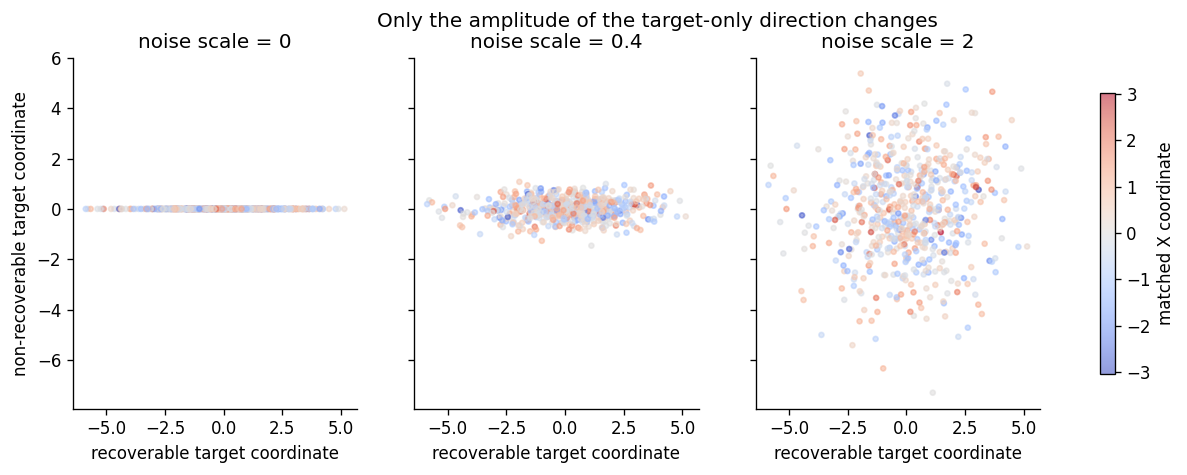

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True, sharey=True)
for ax, noise_scale in zip(axes, (cfg.noise_levels[0], cfg.noise_levels[4], cfg.noise_levels[-1])):
    X, Y = generate_gaussian_with_orthogonal_noise(
        cfg.n_samples,
        orthogonal_noise_scale=noise_scale,
        signal_scales=cfg.signal_scales,
        seed=cfg.seed,
    )
    points = ax.scatter(
        Y[:, 0], Y[:, 2], c=X[:, 1], cmap="coolwarm", s=9, alpha=0.55
    )
    ax.set(
        xlabel="recoverable target coordinate",
        title=f"noise scale = {noise_scale:g}",
    )
# end for ax, noise_scale
axes[0].set_ylabel("non-recoverable target coordinate")
fig.colorbar(points, ax=axes, label="matched X coordinate", shrink=0.8)
fig.suptitle("Only the amplitude of the target-only direction changes")
plt.show()

## Sweep pooled R² and II

For every scale, the pipeline computes both directional metrics on the original
spaces, applies the two reciprocal Σ⁻¹ transforms, and recomputes the metrics.

In [4]:
rows = []
for noise_scale in cfg.noise_levels:
    X, Y = generate_gaussian_with_orthogonal_noise(
        cfg.n_samples,
        orthogonal_noise_scale=noise_scale,
        signal_scales=cfg.signal_scales,
        seed=cfg.seed,
    )
    pipeline = run_asymmetry_pipeline(
        X,
        Y,
        source_metric=cfg.source_RDM_metric,
        target_metric=cfg.target_RDM_metric,
        k=cfg.k,
        relative_tolerance=cfg.singular_value_rtol,
    )

    for stage, fit_result, ii_result in (
        ("original", pipeline["original_fit"], pipeline["original_ii"]),
        ("Sigma^-1 normalized", pipeline["transformed_fit"], pipeline["transformed_ii"]),
    ):
        rows.append(
            {
                "noise scale": noise_scale,
                "stage": stage,
                "R2 X -> Y": fit_result["pooled_r2_source_to_target"],
                "R2 Y -> X": fit_result["pooled_r2_target_to_source"],
                "II X -> Y": ii_result["source_to_target"],
                "II Y -> X": ii_result["target_to_source"],
            }
        )
    # end for stage, fit_result, ii_result
# end for noise_scale

sweep = pd.DataFrame(rows)
sweep["absolute R2 gap"] = abs(sweep["R2 X -> Y"] - sweep["R2 Y -> X"])
sweep["absolute II gap"] = abs(sweep["II X -> Y"] - sweep["II Y -> X"])
display(sweep.style.format(precision=5))

,noise scale,stage,R2 X -> Y,R2 Y -> X,II X -> Y,II Y -> X,absolute R2 gap,absolute II gap
0,0.00000,original,1.00000,1.00000,0.01981,0.01882,0.00000,0.00100
1,0.00000,Sigma^-1 normalized,1.00000,1.00000,0.01981,0.01882,0.00000,0.00100
2,0.05000,original,0.99937,1.00000,0.01997,0.01921,0.00063,0.00077
3,0.05000,Sigma^-1 normalized,1.00000,1.00000,0.01981,0.01882,0.00000,0.00100
4,0.10000,original,0.99748,1.00000,0.02203,0.02265,0.00252,0.00062
5,0.10000,Sigma^-1 normalized,1.00000,1.00000,0.01981,0.01882,0.00000,0.00100
6,0.20000,original,0.99000,1.00000,0.03468,0.03373,0.01000,0.00095
7,0.20000,Sigma^-1 normalized,1.00000,1.00000,0.01981,0.01882,0.00000,0.00100
8,0.40000,original,0.96115,1.00000,0.08253,0.05422,0.03885,0.02831
9,0.40000,Sigma^-1 normalized,1.00000,1.00000,0.01981,0.01882,0.00000,0.00100


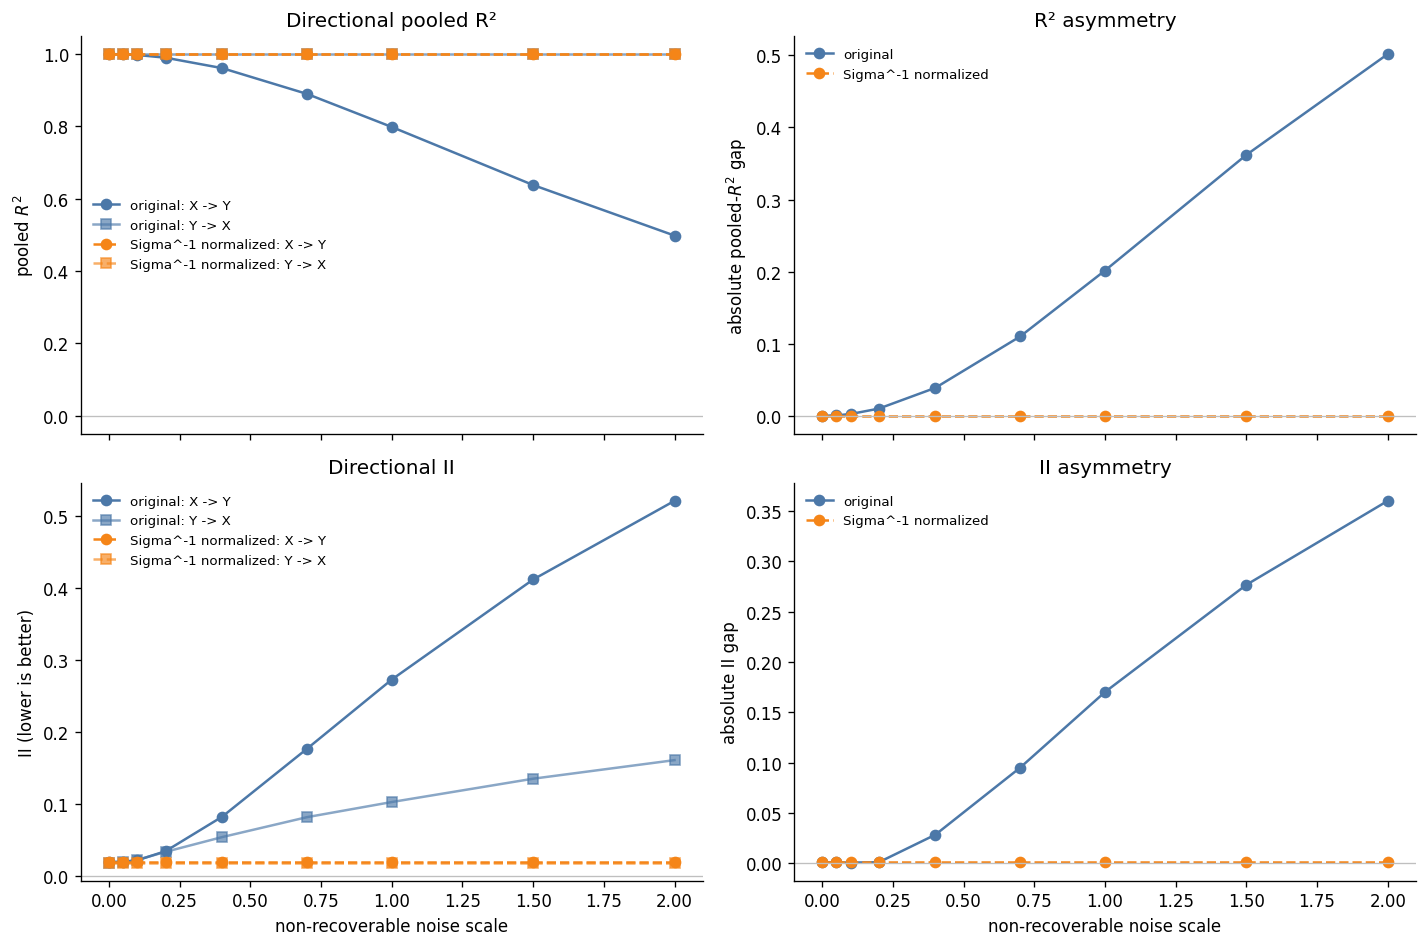

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
stage_styles = {
    "original": {"color": "#4C78A8", "linestyle": "-"},
    "Sigma^-1 normalized": {"color": "#F58518", "linestyle": "--"},
}

for stage, stage_rows in sweep.groupby("stage", sort=False):
    style = stage_styles[stage]
    axes[0, 0].plot(stage_rows["noise scale"], stage_rows["R2 X -> Y"], marker="o", label=f"{stage}: X -> Y", **style)
    axes[0, 0].plot(stage_rows["noise scale"], stage_rows["R2 Y -> X"], marker="s", alpha=0.65, label=f"{stage}: Y -> X", **style)
    axes[0, 1].plot(stage_rows["noise scale"], stage_rows["absolute R2 gap"], marker="o", label=stage, **style)
    axes[1, 0].plot(stage_rows["noise scale"], stage_rows["II X -> Y"], marker="o", label=f"{stage}: X -> Y", **style)
    axes[1, 0].plot(stage_rows["noise scale"], stage_rows["II Y -> X"], marker="s", alpha=0.65, label=f"{stage}: Y -> X", **style)
    axes[1, 1].plot(stage_rows["noise scale"], stage_rows["absolute II gap"], marker="o", label=stage, **style)
# end for stage, stage_rows

axes[0, 0].set(ylabel=r"pooled $R^2$", title="Directional pooled R²")
axes[0, 1].set(ylabel=r"absolute pooled-$R^2$ gap", title="R² asymmetry")
axes[1, 0].set(xlabel="non-recoverable noise scale", ylabel="II (lower is better)", title="Directional II")
axes[1, 1].set(xlabel="non-recoverable noise scale", ylabel="absolute II gap", title="II asymmetry")
for ax in axes.flat:
    ax.axhline(0, color="0.75", linewidth=0.8)
    ax.legend(frameon=False, fontsize=8)
# end for ax in axes.flat
fig.tight_layout()
plt.show()

## Interpretation

`Y -> X` retains access to the complete recoverable block, whereas `X -> Y`
cannot predict the independent coordinate. The original pooled-R² gap therefore
grows with noise amplitude. II measures neighborhood preservation, so its curve
additionally shows when the target-only direction becomes large enough to
reorder target-space nearest neighbors. The normalized curves show which part
of each asymmetry is attributable to singular gains and inactive directions.